In [1]:
import pandas as pd

import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# importing functions from functions.py
from functions import haversine, get_walking_distance, get_district, remove_outliers, apply_jitter

# Cleaning Data

In [3]:
yerevan_actual_raw = pd.read_csv('../database/raw_data/Yerevan actual.csv')

## filtering out duplicates in id 

as historical data keeps track of every price change and classifies a house sold based on if \
the listing for the house was removed. We only need data for the sold houses and filter out duplicates

In [161]:
# Dropping columns
yerevan_actual_raw = yerevan_actual_raw.drop(["OBJECTID", "level_0", "index"], axis = 1)
# Renaming columns
yerevan_actual_raw = yerevan_actual_raw.rename(columns={'date': 'download_date'})

there were a few instances where the same row of data was scraped for the id because the script crashed and restarted \
you can run the below script to confirm that it's the same exact data for every row corresponding the id

yerevan_actual_raw['id'].value_counts() \
yerevan_actual_raw[yerevan_actual_raw['id'] == 19033800]

In [162]:
# Removing duplicates for id
duplicates = yerevan_actual_raw.duplicated(subset=['id'])
yerevan_actual = yerevan_actual_raw[~duplicates].drop_duplicates(subset=['id']).reset_index()

# Generating new features for the data

An aspect of already improving on the data we have, was to add more features (mostly based on the coordinates of the houses) \
Thus in the below script you can find the following new columns generated for each of the houses:
- the district they belong to
- their closest metro station
- walking distance to that metro

This is done in order to understand if any of these spatial variables play a role in affecting the price of the houses once we run the model

## District Regions

as our data has x, y coordinates setup we wrote a script to generate the corresponding district for each point \
this is later used for removing outliers corresponding to each region, creating more interesting visuals in arcgis \
and running the model with the context of the district for each house

### DO NOT!!! Run the script as it takes several hours for the data to be generated

In [163]:
data = yerevan_actual.copy()

In [164]:
count = 0

# an empty DataFrame to store the results
yerevan_districts = pd.DataFrame(columns=['x', 'y', 'district'])

below code gave http request errors sometimes (as a result of the quota for the package) so while, try, except \
were added to the code so that it continues to run the code again after the error

In [165]:
while True:
    # noinspection PyBroadException
    try:
        # Loop through each row of the data and calculate the district for each row
        for i, row in data.iterrows():
            # Calculate the district for the current row
            district = get_district(row['x'], row['y'])
            count = count + 1
            data.drop(index=data.index[0], axis=0, inplace=True)
            # Append the current row to the new DataFrame
            yerevan_districts = yerevan_districts.append({'x': row['x'], 'y': row['y'], 'district': district}, ignore_index=True) 
    except:
        # if there was an error, print a message and try again
        print("An error occurred. Retrying...")
        continue
    else:
        # if there was no error, break out of the loop and continue with the rest of the code
        break

An error occurred. Retrying...


In [ ]:
yerevan_actual["district"] = yerevan_districts["district"]

In [ ]:
# Save the results to a CSV file
yerevan_actual.to_csv('../database/yerevan_actual_clean/Yerevan.csv')

## Metro Distance Calculation

we first use the haversine distance measure to calculate the angular distance between each house and each metro on the surface of a sphere, \
to get the closest metro station for each house

Then we calculate the walking distance between each house and the closest metro corresponding to it, using the Maps API

In [ ]:
yerevan_actual = pd.read_excel('../database/yerevan_actual_clean/Yerevan.xlsx')
houses = yerevan_actual.copy() # houses is used for testing

# Metro Stations in Yerevan
stations = pd.DataFrame({
    'station_id': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'station_name': ['Barekamutyun', 'Baghramyan', 'Yeritasardakan', 'Republic Square', 'Zoravar Andranik',
                     'Sasuntsi Davit', 'Gortsaranain', 'Shengavit', 'Charbakh', 'Garegin Nzhdeh Square'],
    'x': [40.197446, 40.1918167, 40.1873081, 40.1785331, 40.1699272, 40.1552243, 40.1410611, 40.145224,
          40.1405941, 40.1504761],
    'y': [44.493467, 44.5038091, 44.5191743, 44.5134433, 44.5112603, 44.5058011, 44.4964173, 44.48483,
          44.4685333, 44.4816183]
})

#### calculating distance from every house to every metro station and taking shortest metro station

In [ ]:
# Loop through each house and station to find the shortest distance using Haversine
distances = []
station_ids = []
station_names = []
for house_idx, house in houses.iterrows():
    shortest_distance = float('inf')
    nearest_station_name = ''
    for station_idx, station in stations.iterrows():
        distance = haversine(house['y'], house['x'], station['y'], station['x'])
        if distance < shortest_distance:
            shortest_distance = distance
            nearest_station_id = station['station_id']
            nearest_station_name = station['station_name']
    #distances.append(shortest_distance)
    station_ids.append(nearest_station_id)
    station_names.append(nearest_station_name)

# Add the new columns to the houses table
#houses['shortest_distance'] = distances
houses['nearest_station_id'] = station_ids
houses['nearest_station_name'] = station_names

#### we have the closest metro station using haversine distance, now we calculate the walking distance using Google Maps api

In [ ]:
yerevan_actual["closest_metro"] = houses["nearest_station_name"]
distances = []

# Using Google Maps API to calculate the walking distance
for i, house in houses.iterrows():
    distance = get_walking_distance(house['y'], house['x'], stations['y'][house['nearest_station_id']-1], stations['x'][house['nearest_station_id']-1])
    distances.append(distance)
    houses.drop(index=houses.index[0], axis=0, inplace=True)

yerevan_actual["walking_distance_to_metro(m)"] = distances

In [ ]:
# Overwriting Yervan.xlsx file with the new metro and walking distance columns
yerevan_actual.to_csv("../database/yerevan_actual_clean/Yerevan.csv", index=False)

# Outlier detection

In [2]:
yerevan_actual = pd.read_csv('../database/yerevan_actual_clean/Yerevan.csv')

In [3]:
# Drop the rows with missing values
houses_filt = yerevan_actual.dropna(subset=['price'])

In [4]:
# price null values are gone and we separate houses sold from rent
sale = houses_filt.loc[(houses_filt["rent_or_sale"]=="sale appartments") | (houses_filt["rent_or_sale"]=="sale houses")]

In [5]:
# converting armenian text for districts to english
armenian_to_english = {'Աջափնյակ': 'Achapnyak',
                       'Նոր Նորք': 'Nor_Nork',
                       'Արաբկիր': 'Arabkir',
                       'Կենտրոն': 'Kentron',
                       'Դավթաշեն': 'Davtashen',
                       'Էրեբունի': 'Erebuni',
                       'Շենգավիթ': 'Shengavit',
                       'Քանաքեռ-Զեյթուն': 'Qanaqer_Zeytun',
                       'Մալաթիա-Սեբաստիա': 'Malatia_Sebastia',
                       'Ավան': 'Avan',
                       'Նոր Նորքի 1-ին զանգված': 'Nor_Nork',
                       'Նոր Նորքի 2-րդ զանգված': 'Nor_Nork',
                       'Դավթաշեն գյուղ': 'Davtashen',
                       'Նորք Մարաշ': 'Norq_Marash',
                       'Գլենդել Հիլզ': 'Kentron',
                       'Նուբարաշեն': 'Nubarashen',
                       'Հաղթանակ': 'Malatia_Sebastia',
                       'Նոյ թաղամաս': 'Malatia_Sebastia',
                       'Մուշ թաղամաս': 'Malatia_Sebastia',
                       'Էկո քաղաք': 'Achapnyak'}

sale['district'] = sale['district'].replace(armenian_to_english)

### Box-Plot

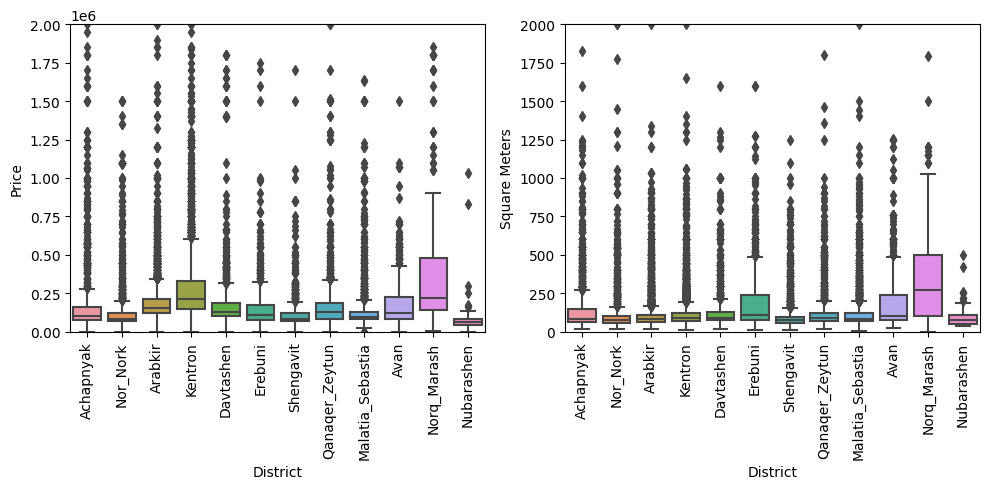

In [6]:
# Create a figure with two subplots
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(10, 5))

# Plot the price boxplot on the first subplot
sns.boxplot(x='district', y='price', data=sale, ax=ax1)
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=90)
ax1.set_ylim(0, 2000000)
ax1.set_xlabel('District')
ax1.set_ylabel('Price')

# Plot the square_meters boxplot on the second subplot
sns.boxplot(x='district', y='square_meters', data=sale, ax=ax2)
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=90)
ax2.set_ylim(0, 2000)
ax2.set_xlabel('District')
ax2.set_ylabel('Square Meters')

# Show the plot
plt.tight_layout()
plt.show()

### IQR


removing outlier values using IQR method described in the functions.py

In [9]:
sale = remove_outliers(sale, 'price', 5000)

District Achapnyak has 207 outliers
District Arabkir has 384 outliers
District Avan has 59 outliers
District Davtashen has 136 outliers
District Erebuni has 79 outliers
District Kentron has 458 outliers
District Malatia_Sebastia has 224 outliers
District Nor_Nork has 181 outliers
District Norq_Marash has 29 outliers
District Nubarashen has 9 outliers
District Qanaqer_Zeytun has 142 outliers
District Shengavit has 120 outliers


In [10]:
sale = remove_outliers(sale, 'square_meters', 40)

District Achapnyak has 220 outliers
District Arabkir has 322 outliers
District Avan has 60 outliers
District Davtashen has 137 outliers
District Erebuni has 114 outliers
District Kentron has 676 outliers
District Malatia_Sebastia has 229 outliers
District Nor_Nork has 150 outliers
District Norq_Marash has 7 outliers
District Nubarashen has 5 outliers
District Qanaqer_Zeytun has 197 outliers
District Shengavit has 328 outliers


## Spatial Jittering


the long and lat points are generated by mapping the address to the points corresponding on the map. \
As a lot of users don't define exact locations and have general addresses of where it is the same coordinate is matched for many locations

this causes issues when we try to run spatial forest based regression, as it won't identify the exact nearest neighbor to the house in question. \
Thus, we jitter each and every house very slightly by a random very small value


In [11]:
jitter_distance = 0.00001  # Adjust this value according to the desired jitter distance
sale['latitude_jittered'] = sale['y'].apply(lambda x: apply_jitter(x, jitter_distance))
sale['longitude_jittered'] = sale['x'].apply(lambda x: apply_jitter(x, jitter_distance))
grouped_df = sale.groupby(['latitude_jittered', 'longitude_jittered']).size().reset_index(name='count')

sorted_grouped_data = grouped_df.sort_values('count', ascending=False)

most_frequent_coords = sorted_grouped_data.head()
print(most_frequent_coords)

       latitude_jittered  longitude_jittered  count
0              44.409844           40.164140      1
12529          44.516444           40.150497      1
12545          44.516455           40.150497      1
12544          44.516453           40.150496      1
12543          44.516453           40.150501      1


In [ ]:
sale.to_csv("../database/yerevan_actual_clean/sale_actual.csv", index=False)